In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
import numpy as np
import pandas as pd
import os

train_dir = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
test_dir  = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"

classes      = sorted(os.listdir(train_dir))
num_classes  = len(classes)

print("=" * 40)
print("     INTEL IMAGE CLASSIFICATION")
print("=" * 40)
print(f"  Classes      : {num_classes}")
for cls in classes:
    train_count = len(os.listdir(os.path.join(train_dir, cls)))
    test_count  = len(os.listdir(os.path.join(test_dir,  cls)))
    print(f"  {cls:<12} : {train_count} train | {test_count} test")
print("=" * 40)

     INTEL IMAGE CLASSIFICATION
  Classes      : 6
  buildings    : 2191 train | 437 test
  forest       : 2271 train | 474 test
  glacier      : 2404 train | 553 test
  mountain     : 2512 train | 525 test
  sea          : 2274 train | 510 test
  street       : 2382 train | 501 test


In [5]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from transformers import ViTMAEModel

In [7]:
TRAIN_DIR   = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DIR    = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
CLASS_NAMES = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 20

In [8]:
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

print("Train samples :", len(train_dataset))
print("Test  samples :", len(test_dataset))
print("Classes       :", train_dataset.classes)

Train samples : 14034
Test  samples : 3000
Classes       : ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches :", len(train_loader))
print("Test  batches :", len(test_loader))

Train batches : 439
Test  batches : 94


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device :", device)

if torch.cuda.is_available():
    print("GPU name     :", torch.cuda.get_device_name(0))
    print("VRAM (GB)    :", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

Using device : cuda
GPU name     : Tesla T4
VRAM (GB)    : 15.64


In [11]:
encoder = ViTMAEModel.from_pretrained("facebook/vit-mae-base")

hidden_size = encoder.config.hidden_size

classifier_head = nn.Sequential(
    nn.LayerNorm(hidden_size),
    nn.Linear(hidden_size, 512),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)

model = nn.Sequential()
model.encoder         = encoder
model.classifier_head = classifier_head

def forward(pixel_values):
    outputs         = encoder(pixel_values=pixel_values, noise=None)
    cls_token       = outputs.last_hidden_state[:, 0, :]
    logits          = classifier_head(cls_token)
    return logits

total_params     = sum(p.numel() for p in encoder.parameters()) + \
                   sum(p.numel() for p in classifier_head.parameters())
trainable_params = total_params

encoder.to(device)
classifier_head.to(device)

print("Total parameters     :", f"{total_params:,}")
print("Trainable parameters :", f"{trainable_params:,}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                              | Status     |  | 
---------------------------------------------------------------------------------+------------+--+-
decoder.mask_token                                                               | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.output.dense.weight              | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.value.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.weight           | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.attention.key.bias     | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_after.bias             | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.

Total parameters     : 86,196,998
Trainable parameters : 86,196,998


In [12]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print("Loss function :", criterion)

Loss function : CrossEntropyLoss()


In [13]:
optimizer = optim.AdamW([
    {"params": encoder.parameters(),         "lr": 1e-5, "weight_decay": 0.05},
    {"params": classifier_head.parameters(), "lr": 1e-4, "weight_decay": 0.01},
])

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=1e-7
)

print("Optimizer : AdamW (encoder lr=1e-5, classifier lr=1e-4)")
print("Scheduler : CosineAnnealingLR T_max=", NUM_EPOCHS)

Optimizer : AdamW (encoder lr=1e-5, classifier lr=1e-4)
Scheduler : CosineAnnealingLR T_max= 20


In [14]:
scaler       = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
epoch_losses = []
start_time   = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    encoder.train()
    classifier_head.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = forward(images)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(
            list(encoder.parameters()) + list(classifier_head.parameters()),
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    scheduler.step()

    avg_loss       = running_loss / len(train_loader)
    epoch_time     = time.time() - start_time
    epochs_done    = epoch
    epochs_left    = NUM_EPOCHS - epoch

    epoch_losses.append(avg_loss)

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}] Loss: {avg_loss:.4f} | "
          f"Finished: {epochs_done}/{NUM_EPOCHS} | "
          f"Remaining: {epochs_left} | "
          f"Elapsed: {epoch_time/60:.1f} min")

training_time = time.time() - start_time

print(f"\nTraining complete in {training_time:.2f}s ({training_time/60:.2f} min)")

/tmp/ipykernel_323/1427353963.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler       = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipykernel_323/1427353963.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Epoch [01/20] Loss: 0.7533 | Finished: 1/20 | Remaining: 19 | Elapsed: 1.2 min
Epoch [02/20] Loss: 0.6028 | Finished: 2/20 | Remaining: 18 | Elapsed: 2.5 min
Epoch [03/20] Loss: 0.5832 | Finished: 3/20 | Remaining: 17 | Elapsed: 3.7 min
Epoch [04/20] Loss: 0.5675 | Finished: 4/20 | Remaining: 16 | Elapsed: 4.9 min
Epoch [05/20] Loss: 0.5567 | Finished: 5/20 | Remaining: 15 | Elapsed: 6.1 min
Epoch [06/20] Loss: 0.5465 | Finished: 6/20 | Remaining: 14 | Elapsed: 7.3 min
Epoch [07/20] Loss: 0.5359 | Finished: 7/20 | Remaining: 13 | Elapsed: 8.6 min
Epoch [08/20] Loss: 0.5304 | Finished: 8/20 | Remaining: 12 | Elapsed: 9.8 min
Epoch [09/20] Loss: 0.5267 | Finished: 9/20 | Remaining: 11 | Elapsed: 11.0 min
Epoch [10/20] Loss: 0.5207 | Finished: 10/20 | Remaining: 10 | Elapsed: 12.3 min
Epoch [11/20] Loss: 0.5106 | Finished: 11/20 | Remaining: 9 | Elapsed: 13.5 min
Epoch [12/20] Loss: 0.5100 | Finished: 12/20 | Remaining: 8 | Elapsed: 14.7 min
Epoch [13/20] Loss: 0.5022 | Finished: 13/20 | 

In [15]:
# EVALUATION

encoder.eval()
classifier_head.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = forward(images)

        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall    = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1        = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

print("Accuracy  :", round(accuracy, 4), f"({accuracy*100:.2f}%)")
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

/tmp/ipykernel_323/3922147159.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


Accuracy  : 0.94 (94.00%)
Precision : 0.94
Recall    : 0.94
F1 Score  : 0.9398


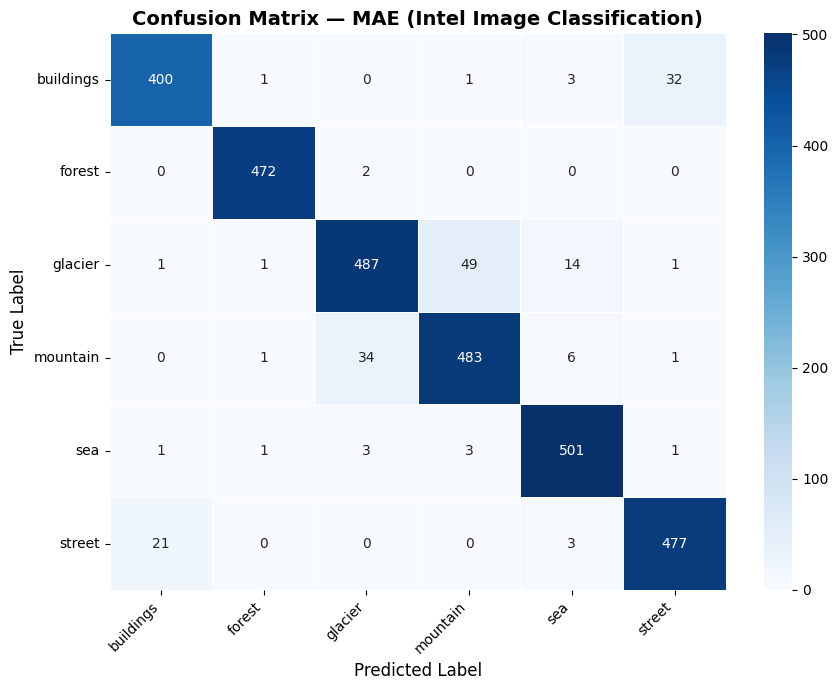

In [17]:
# CONFUSION MATRIX

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    linewidths=0.5
)

plt.title("Confusion Matrix — MAE (Intel Image Classification)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

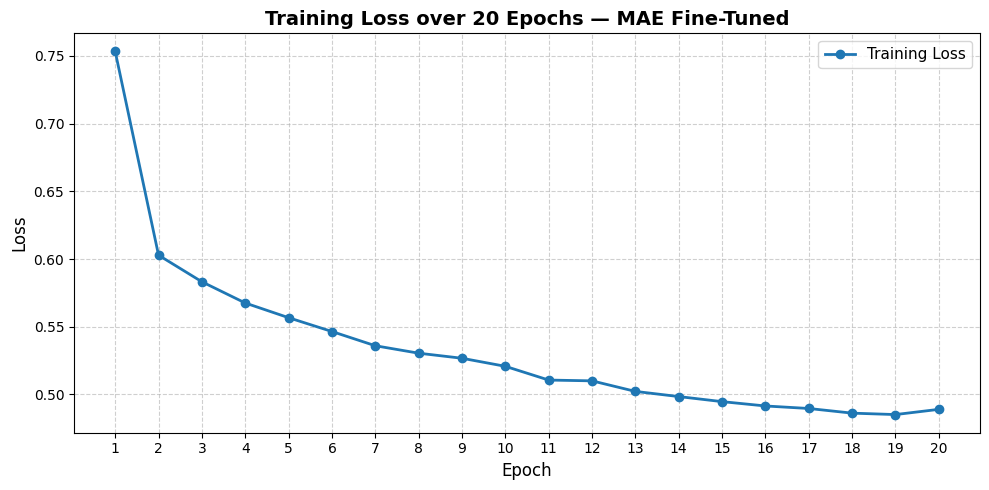

In [18]:
# LOSS GRAPH

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    epoch_losses,
    marker="o",
    linewidth=2,
    color="#1f77b4",
    label="Training Loss"
)

plt.title("Training Loss over 20 Epochs — MAE Fine-Tuned", fontsize=14, fontweight="bold")
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150, bbox_inches="tight")
plt.show()